## Six-class schema notice

This notebook now uses the canonical 19-band, six-class pipeline. Existing embedded figures/output were produced before Agriculture label 5 and are historical until all cells are rerun.


In [1]:
import os
import ee
import geemap
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()
ee.Initialize(project=os.getenv('EE_PROJECT_ID'))

os.makedirs('../../../doc/assets', exist_ok=True)

/Users/ashutoshsaxena/Library/Python/3.9/lib/python/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/ashutoshsaxena/Library/Python/3.9/lib/python/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/ashutoshsaxena/Library/Python/3.9/lib/python/site-packages/google/api_core/_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9

In [ ]:
# Canonical six-class / 19-band schema shared with backend and evaluation runner.
from backend.config import BANDS, FEATURE_COLLECTIONS, LAND_COVER_CLASSES, SEASONS
from backend.gee_classifier import build_sentinel_composite, merge_feature_collections, sample_training_points

PRE_AGRICULTURE_OUTPUTS = True  # Embedded outputs below predate label 5 until this notebook is rerun.
bands = BANDS
class_names = [LAND_COVER_CLASSES[i]["name"] for i in LAND_COVER_CLASSES]
class_palette = [LAND_COVER_CLASSES[i]['color'].lstrip('#') for i in LAND_COVER_CLASSES]
legend_dict = {f"{info['name']} ({label})": info['color'].lstrip('#')
               for label, info in LAND_COVER_CLASSES.items()}


In [2]:
# ----- Define Jabalpur District Boundary -----
jabalpur = (
    ee.FeatureCollection('FAO/GAUL/2015/level2')
      .filter(ee.Filter.eq('ADM2_NAME', 'Jabalpur'))
      .geometry()
)

# ----- Cloud Masking -----
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud  = 1 << 10
    cirrus = 1 << 11
    mask = qa.bitwiseAnd(cloud).eq(0).And(qa.bitwiseAnd(cirrus).eq(0))
    return image.updateMask(mask).divide(10000)

# ----- Sentinel-2 Composite -----
# Extended to full dry season for gap-free coverage over the entire district.
# Scene-level cloud filter relaxed to 50% — per-pixel QA60 masking handles
# individual cloudy pixels, so we just need enough scenes in the collection.
dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterDate(season['start'], season['end'])
      .filterBounds(jabalpur)
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50))
      .map(mask_s2_clouds)
)

print('Number of images in collection:', dataset.size().getInfo())

composite = dataset.median().clip(jabalpur)

# ----- Spectral Indices -----
ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
ndwi = composite.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndbi = composite.normalizedDifference(['B11', 'B8']).rename('NDBI')
savi = composite.expression(
    '1.5 * (NIR - RED) / (NIR + RED + 0.5)',
    {'NIR': composite.select('B8'), 'RED': composite.select('B4')}
).rename('SAVI')

composite = composite.addBands([ndvi, ndwi, ndbi, savi])
bands = BANDS
# Canonical feature composite override: exact Summer dates and all retained 19 bands.
season = SEASONS["summer"]
composite = build_sentinel_composite(jabalpur, season["start"], season["end"])
bands = BANDS


Number of images in collection: 187


In [ ]:
# Load every configured current asset; this includes repositioned Jabalpur water
# (1,000 points), MP soil/sand, and Agriculture label 5. Legacy water_points (100)
# is intentionally never referenced.
class_names = [LAND_COVER_CLASSES[i]["name"] for i in LAND_COVER_CLASSES]
class_collections = [ee.FeatureCollection(path) for path in FEATURE_COLLECTIONS.values()]
all_points = merge_feature_collections(FEATURE_COLLECTIONS.values())

def assign_block(feature):
    coords = feature.geometry().coordinates()
    bx = ee.Number(coords.get(0)).multiply(10).floor()
    by = ee.Number(coords.get(1)).multiply(10).floor()
    return feature.set("blk", bx.multiply(31).add(by.multiply(17)).mod(10))

blocked_points = all_points.map(assign_block)
season = SEASONS["summer"]
train_set = sample_training_points(
    blocked_points.filter(ee.Filter.lt("blk", 7)),
    start_date=season["start"], end_date=season["end"],
)
test_set = sample_training_points(
    blocked_points.filter(ee.Filter.gte("blk", 7)),
    start_date=season["start"], end_date=season["end"],
)
training = train_set.merge(test_set)

print("--- Canonical point assets ---")
for key, collection in zip(FEATURE_COLLECTIONS, class_collections):
    print(key, collection.size().getInfo())
print("Train Set Size:", train_set.size().getInfo())
print("Test Set Size:", test_set.size().getInfo())


Overall Accuracy: 0.813953488372093


Kappa Coefficient: 0.7428261927243938



--- Confusion Matrix Shape Check ---
Rows: 4 Cols: 4
[[221, 4, 4, 3], [0, 127, 18, 12], [4, 1, 111, 29], [18, 15, 60, 276]]

--- Class-wise Accuracy ---


Forest: Consumer's = 0.9095, Producer's = 0.9526
Water: Consumer's = 0.8639, Producer's = 0.8089
Buildings: Consumer's = 0.5751, Producer's = 0.7655
Soil: Consumer's = 0.8625, Producer's = 0.7480



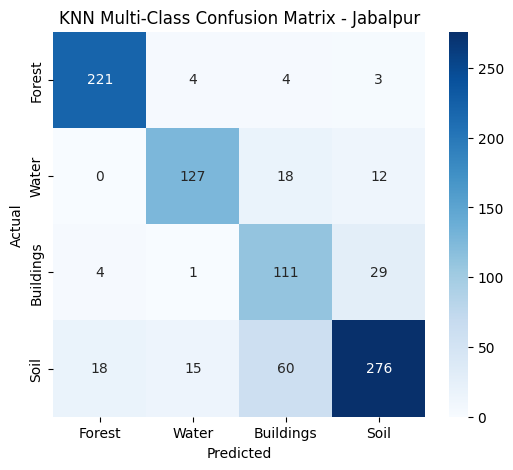

In [4]:
knn_classifier = ee.Classifier.smileKNN(
    k=5,
    searchMethod='AUTO',
    metric='EUCLIDEAN'
).train(
    features=train_set,
    classProperty='label',
    inputProperties=bands
)

# ----- Evaluate on Test Set -----
test_classified = test_set.classify(knn_classifier)
confusion_matrix = test_classified.errorMatrix('label', 'classification')

print('Overall Accuracy:', confusion_matrix.accuracy().getInfo())
print('Kappa Coefficient:', confusion_matrix.kappa().getInfo())

# --- Matrix shape / sanity check (Step 2) ---
# Confirms the confusion matrix is actually 4x4 and shows the raw
# counts, so a missing/empty row or column is visible directly
# instead of being masked by a misleading 0.0000 accuracy value.
cm_array = confusion_matrix.array().getInfo()
print('\n--- Confusion Matrix Shape Check ---')
print('Rows:', len(cm_array), 'Cols:', len(cm_array[0]) if cm_array else 0)
print(cm_array)

# --- Class-wise Accuracy (Step 3: label-aligned, not position-flattened) ---
# errorMatrix.order() returns the actual label order GEE used to build
# the matrix. Mapping consumers/producers accuracy through this order
# (instead of assuming positions 0,1,2,3 line up with class_names)
# means a genuinely missing class shows up as NaN, not a silent 0.0000.
print('\n--- Class-wise Accuracy ---')
order = confusion_matrix.order().getInfo()
consumers_acc = confusion_matrix.consumersAccuracy().getInfo()
producers_acc = confusion_matrix.producersAccuracy().getInfo()

ca_flat = [item for sublist in consumers_acc for item in sublist]
pa_flat = [item for sublist in producers_acc for item in sublist]

ca_by_label = dict(zip(order, ca_flat))
pa_by_label = dict(zip(order, pa_flat))

for i, name in enumerate(class_names):
    ca = ca_by_label.get(i, float('nan'))
    pa = pa_by_label.get(i, float('nan'))
    print(f"{name}: Consumer's = {ca:.4f}, Producer's = {pa:.4f}")

print()

# ----- Confusion Matrix Heatmap -----
plt.figure(figsize=(6, 5))
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Multi-Class Confusion Matrix - Jabalpur')
plt.savefig('../../../doc/assets/multi_knn_jabalpur_cm.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# ----- Classify and Visualise -----
classified = composite.select(bands).classify(knn_classifier)
classified_smooth = classified.focalMode(radius=1, kernelType='square', units='pixels')

class_palette = [LAND_COVER_CLASSES[i]['color'].lstrip('#') for i in LAND_COVER_CLASSES]

Map = geemap.Map(center=[23.18, 79.95], zoom=10)
Map.addLayer(composite, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'RGB Composite')
Map.addLayer(classified_smooth, {'min': 0, 'max': len(LAND_COVER_CLASSES) - 1, 'palette': class_palette}, 'CART Classification')

legend_dict = {f"{info['name']} ({label})": info['color'].lstrip('#') for label, info in LAND_COVER_CLASSES.items()}
Map.add_legend(title='Land Cover', legend_dict=legend_dict)
Map.addLayer(jabalpur, {}, 'Jabalpur Boundary')
Map

Map(center=[23.18, 79.95], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [6]:
# ----- Class-wise Area Calculation -----
area_image = ee.Image.pixelArea().addBands(classified_smooth)
areas = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
    geometry=jabalpur,
    scale=30,
    maxPixels=1e13,
    tileScale=4
)

area_data = areas.getInfo()['groups']
print('--- Class Areas (Hectares) ---')
for entry in area_data:
    ha = entry['sum'] / 10000
    print(f"{class_names[entry['class']]}: {ha:.2f} ha")

--- Class Areas (Hectares) ---
Forest: 140829.33 ha
Water: 21042.91 ha
Buildings: 74470.85 ha
Soil: 164822.00 ha
